In [1]:
#Importação das bibliotecas necessárias
import pandas as pd
import numpy as np

In [2]:
#Carregamento da base de dados
uniao = pd.read_csv('/content/state_idh_pib.csv')

####################LIMPEZA E AJUSTES NOS DADOS##############################################


In [3]:
#COLUNA TARGET
#Verificação dos valories unicos para posteriormente reduzir o numero de faixas
uniao['Faixa_Salarial'].unique()

array(['de R$ 12.001/mês a R$ 16.000/mês',
       'de R$ 6.001/mês a R$ 8.000/mês', nan,
       'de R$ 4.001/mês a R$ 6.000/mês',
       'de R$ 8.001/mês a R$ 12.000/mês',
       'de R$ 20.001/mês a R$ 25.000/mês',
       'de R$ 1.001/mês a R$ 2.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
       'de R$ 16.001/mês a R$ 20.000/mês',
       'de R$ 2.001/mês a R$ 3.000/mês', 'Acima de R$ 40.001/mês',
       'de R$ 25.001/mês a R$ 30.000/mês', 'Menos de R$ 1.000/mês',
       'de R$ 30.001/mês a R$ 40.000/mês', 'de R$ 101/mês a R$ 2.000/mês'],
      dtype=object)

In [4]:
#Verificação dos dados NaN para posterior exclusão das linhas
total_nan = uniao['Faixa_Salarial'].isna().sum()
print(f"Total de valores NaN: {total_nan}")

Total de valores NaN: 540


In [5]:
#Exclusão das linhas com valores Nan
uniao_sem_nan = uniao.dropna(subset=['Faixa_Salarial'])

In [6]:
#Verificação do resultado
contagem_valores = uniao_sem_nan ['Faixa_Salarial'].value_counts()
print(contagem_valores)

Faixa_Salarial
de R$ 8.001/mês a R$ 12.000/mês     1026
de R$ 4.001/mês a R$ 6.000/mês       745
de R$ 12.001/mês a R$ 16.000/mês     650
de R$ 6.001/mês a R$ 8.000/mês       637
de R$ 3.001/mês a R$ 4.000/mês       352
de R$ 16.001/mês a R$ 20.000/mês     328
de R$ 2.001/mês a R$ 3.000/mês       288
de R$ 1.001/mês a R$ 2.000/mês       215
de R$ 20.001/mês a R$ 25.000/mês     195
de R$ 25.001/mês a R$ 30.000/mês     128
de R$ 30.001/mês a R$ 40.000/mês      86
Acima de R$ 40.001/mês                72
Menos de R$ 1.000/mês                 30
de R$ 101/mês a R$ 2.000/mês           1
Name: count, dtype: int64


In [7]:
# Lista das faixas que queremos REMOVER
faixas_remover = [
    'de R$ 101/mês a R$ 2.000/mês'
]

# Filtra o DataFrame, mantendo apenas as linhas que NÃO estão em 'faixas_remover'
uniao_filtrado = uniao_sem_nan.loc[~uniao_sem_nan['Faixa_Salarial'].isin(faixas_remover)]

# Verifica a contagem atualizada
contagem_filtrada = uniao_filtrado['Faixa_Salarial'].value_counts()
print(contagem_filtrada)

Faixa_Salarial
de R$ 8.001/mês a R$ 12.000/mês     1026
de R$ 4.001/mês a R$ 6.000/mês       745
de R$ 12.001/mês a R$ 16.000/mês     650
de R$ 6.001/mês a R$ 8.000/mês       637
de R$ 3.001/mês a R$ 4.000/mês       352
de R$ 16.001/mês a R$ 20.000/mês     328
de R$ 2.001/mês a R$ 3.000/mês       288
de R$ 1.001/mês a R$ 2.000/mês       215
de R$ 20.001/mês a R$ 25.000/mês     195
de R$ 25.001/mês a R$ 30.000/mês     128
de R$ 30.001/mês a R$ 40.000/mês      86
Acima de R$ 40.001/mês                72
Menos de R$ 1.000/mês                 30
Name: count, dtype: int64


In [9]:
# Definindo o mapeamento para 4 faixas
mapeamento_3faixas = {

    'Menos de R$ 1.000/mês': 'BAIXO: (R$1.000-R$6.000)',
    'de R$ 1.001/mês a R$ 2.000/mês': 'BAIXO: (R$1.000-R$6.000)',
    'de R$ 2.001/mês a R$ 3.000/mês': 'BAIXO: (R$1.000-R$6.000)',
    'de R$ 3.001/mês a R$ 4.000/mês': 'BAIXO: (R$1.000-R$6.000)',
    'de R$ 4.001/mês a R$ 6.000/mês': 'BAIXO: (R$1.000-R$6.000)',
    'de R$ 6.001/mês a R$ 8.000/mês': 'MEDIO: (R$6.001-R$12.000)',
    'de R$ 8.001/mês a R$ 12.000/mês': 'MEDIO: (R$6.001-R$12.000)',
    'de R$ 12.001/mês a R$ 16.000/mês': 'ALTO: (R$12.001-R$40.000 ou +)',
    'de R$ 16.001/mês a R$ 20.000/mês': 'ALTO: (R$12.001-R$40.000 ou +)',
    'de R$ 20.001/mês a R$ 25.000/mês': 'ALTO: (R$12.001-R$40.000 ou +)',
    'de R$ 25.001/mês a R$ 30.000/mês': 'ALTO: (R$12.001-R$40.000 ou +)',
    'de R$ 30.001/mês a R$ 40.000/mês': 'ALTO: (R$12.001-R$40.000 ou +)',
    'Acima de R$ 40.001/mês': 'ALTO: (R$12.001-R$40.000 ou +)'
}

# Aplicando o novo mapeamento
uniao_filtrado['Nivel_Salarial'] = uniao_filtrado['Faixa_Salarial'].map(mapeamento_3faixas)

# Verificando se todas as linhas foram classificadas
if uniao_filtrado['Nivel_Salarial'].isna().any():
    print("Atenção: Algumas faixas não foram mapeadas:")
    print(uniao_filtrado[uniao_filtrado['Nivel_Salarial'].isna()]['Faixa_Salarial'].unique())
else:
    print("Todas as faixas foram classificadas com sucesso!")

# Mostrando a distribuição final
distribuicao = uniao_filtrado['Nivel_Salarial'].value_counts().sort_index()
print("\nDistribuição final (4 faixas):\n", distribuicao)

Todas as faixas foram classificadas com sucesso!

Distribuição final (4 faixas):
 Nivel_Salarial
ALTO: (R$12.001-R$40.000 ou +)    1459
BAIXO: (R$1.000-R$6.000)          1630
MEDIO: (R$6.001-R$12.000)         1663
Name: count, dtype: int64


<ipython-input-9-1b2183b60915>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Nivel_Salarial'] = uniao_filtrado['Faixa_Salarial'].map(mapeamento_3faixas)


In [10]:
# Definir os limites das faixas
bins = [18, 30, 40, 50, 70]  # 18-29, 30-39, 40-49, 50-69
labels = ['18-29 anos', '30-39 anos', '40-49 anos', '50+ anos']

# Criar a nova coluna
uniao_filtrado['Faixa_Etaria'] = pd.cut(
    uniao_filtrado['Idade'],
    bins=bins,
    labels=labels,
    right=False  # Inclui o limite inferior (ex: 30 entra em "30-39")
)

# Verificar a distribuição
print(uniao_filtrado['Faixa_Etaria'].value_counts().sort_index())

Faixa_Etaria
18-29 anos    2081
30-39 anos    1989
40-49 anos     543
50+ anos       138
Name: count, dtype: int64


<ipython-input-10-31d7e6b8059d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Faixa_Etaria'] = pd.cut(


In [11]:
# Dicionário de mapeamento
mapeamento = {
    '18-29 anos': 1,
    '30-39 anos': 2,
    '40-49 anos': 3,
    '50+ anos': 4
}

# Aplicando o mapeamento na coluna
uniao_filtrado['Faixa_Etaria'] = uniao_filtrado['Faixa_Etaria'].map(mapeamento)
print(uniao_filtrado['Faixa_Etaria'].value_counts())

Faixa_Etaria
1    2081
2    1989
3     543
4     138
Name: count, dtype: int64


<ipython-input-11-27c1942d846a>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uniao_filtrado['Faixa_Etaria'] = uniao_filtrado['Faixa_Etaria'].map(mapeamento)


In [12]:
# Contar valores NaN antes da exclusão
print(f"Total de linhas ANTES da exclusão: {len(uniao_filtrado)}")
print(f"Valores NaN na coluna 'Uf': {uniao_filtrado['Uf'].isna().sum()}")

# Excluir linhas com NaN na coluna 'Uf'
uniao_filtrado = uniao_filtrado.dropna(subset=['Uf'])

# Verificar resultado
print(f"\nTotal de linhas APÓS exclusão: {len(uniao_filtrado)}")
print(f"Valores NaN restantes em 'Uf': {uniao_filtrado['Uf'].isna().sum()}")

Total de linhas ANTES da exclusão: 4752
Valores NaN na coluna 'Uf': 103

Total de linhas APÓS exclusão: 4649
Valores NaN restantes em 'Uf': 0


In [13]:
#Contagem de valores únicos
contagem_valores = uniao_filtrado['Nivel_de_Ensino'].value_counts(dropna=False)
print(contagem_valores)

Nivel_de_Ensino
Pós-graduação                 1671
Graduação/Bacharelado         1612
Mestrado                       572
Estudante de Graduação         529
Doutorado ou Phd               181
Não tenho graduação formal      79
Prefiro não informar             5
Name: count, dtype: int64


In [14]:
# Valores que serão removidos
valores_remover = ['Não tenho graduação formal', 'Prefiro não informar']

# Filtrar o DataFrame, mantendo apenas as linhas que NÃO estão nos valores a remover
uniao_filtrado = uniao_filtrado[~uniao_filtrado['Nivel_de_Ensino'].isin(valores_remover)]

# Verificar o resultado
print("Valores únicos em 'Nivel_de_Ensino' após exclusão:")
print(uniao_filtrado['Nivel_de_Ensino'].value_counts())

Valores únicos em 'Nivel_de_Ensino' após exclusão:
Nivel_de_Ensino
Pós-graduação             1671
Graduação/Bacharelado     1612
Mestrado                   572
Estudante de Graduação     529
Doutorado ou Phd           181
Name: count, dtype: int64


In [15]:
# Dicionário de mapeamento
mapeamento = {
    'Estudante de Graduação': 1,
    'Graduação/Bacharelado': 2,
    'Pós-graduação': 3,
    'Mestrado': 4,
    'Doutorado ou Phd': 5
}

# Substitui a coluna original (ou cria uma nova, se preferir)
uniao_filtrado['Nivel_de_Ensino'] = uniao_filtrado['Nivel_de_Ensino'].map(mapeamento)
print(uniao_filtrado['Nivel_de_Ensino'].value_counts())

Nivel_de_Ensino
3    1671
2    1612
4     572
1     529
5     181
Name: count, dtype: int64


In [16]:
# Contagem de valores unicos coluna 'Area_de_Formacao'
contagem_valores = uniao_filtrado['Area_de_Formacao'].value_counts(dropna=False)
print(contagem_valores)

Area_de_Formacao
Computação / Engenharia de Software / Sistemas de Informação/ TI          1894
Outras Engenharias                                                         981
Economia/ Administração / Contabilidade / Finanças/ Negócios               723
Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais     333
Outra opção                                                                232
Marketing / Publicidade / Comunicação / Jornalismo                         120
Química / Física                                                           113
Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde                      97
Ciências Sociais                                                            72
Name: count, dtype: int64


In [17]:
# Contagem de valores unicos coluna 'Area_de_Formacao'
contagem_valores = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].value_counts(dropna=False)
print(contagem_valores)

Tempo_de_experiencia_na_area_de_dados
de 1 a 2 anos                             1161
de 3 a 4 anos                             1075
Mais de 10 anos                            529
Menos de 1 ano                             454
de 4 a 6 anos                              440
de 7 a 10 anos                             403
de 5 a 6 anos                              349
Não tenho experiência na área de dados     154
Name: count, dtype: int64


In [18]:
# Contagem de valores unicos coluna 'Nível'
contagem_valores = uniao_filtrado['Nível'].value_counts(dropna=False)
print(contagem_valores)

Nível
Sênior    1369
Pleno     1341
Júnior    1002
NaN        853
Name: count, dtype: int64


In [19]:
# Excluir linhas com NaN na coluna 'Nível'
#uniao_filtrado = uniao_filtrado.dropna(subset=['Nível'])

# Verificar resultado
#print(f"\nTotal de linhas APÓS exclusão: {len(uniao_filtrado)}")
#print(f"Valores NaN restantes em 'Nível': {uniao_filtrado['Nível'].isna().sum()}")

In [20]:
# Mapeamento desejado
mapeamento_nivel = {
    "Sênior": 3,
    "Pleno": 2,
    "Júnior": 1
}

# Aplicando o mapeamento
uniao_filtrado["Nível"] = uniao_filtrado["Nível"].map(mapeamento_nivel)


In [21]:
# Contagem de valores unicos coluna 'Setor'
contagem_valores = uniao_filtrado['Setor'].value_counts(dropna=False)
print(contagem_valores)

Setor
Finanças ou Bancos                     903
Tecnologia/Fábrica de Software         820
Varejo                                 377
Área de Consultoria                    364
Outra Opção                            320
Indústria                              303
Educação                               205
Área da Saúde                          197
Setor Público                          171
Internet/Ecommerce                     124
Telecomunicação                        109
Marketing                              108
Setor Alimentício                      100
Agronegócios                            91
Setor de Energia                        83
Seguros ou Previdência                  65
Setor Imobiliário/ Construção Civil     64
Entretenimento ou Esportes              58
Setor Automotivo                        48
Setor Farmaceutico                      28
Filantropia/ONG's                       27
Name: count, dtype: int64


In [22]:
# Contagem de valores unicos coluna 'Python'
contagem_valores = uniao_filtrado['Python'].value_counts(dropna=False)
print(contagem_valores)

Python
1.0    2726
NaN     935
0.0     904
Name: count, dtype: int64


In [23]:
# Substitui NaN por 0 na coluna 'Python'
uniao_filtrado['Python'] = uniao_filtrado['Python'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'Python' após substituição:")
print(uniao_filtrado['Python'].value_counts(dropna=False))

Valores na coluna 'Python' após substituição:
Python
1.0    2726
0.0    1839
Name: count, dtype: int64


In [24]:
# Contagem de valores da coluna R
contagem_valores = uniao_filtrado['R'].value_counts(dropna=False)
print(contagem_valores)

R
0.0    3233
NaN     935
1.0     397
Name: count, dtype: int64


In [25]:
# Substitui NaN por 0 na coluna 'R'
uniao_filtrado['R'] = uniao_filtrado['R'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'R' após substituição:")
print(uniao_filtrado['R'].value_counts(dropna=False))

Valores na coluna 'R' após substituição:
R
0.0    4168
1.0     397
Name: count, dtype: int64


In [26]:
# Contagem de valores unicos coluna 'IDHM'
contagem_valores = uniao_filtrado['IDHM'].value_counts(dropna=False)
print(contagem_valores)

IDHM
0.806    1861
0.774     490
0.762     393
0.769     385
0.771     353
0.792     229
0.814     152
0.691     124
0.734     110
0.719     100
0.737      78
0.698      47
0.736      43
0.690      41
0.728      36
0.700      31
0.742      26
0.684      25
0.702      18
0.676      16
0.688       4
0.731       3
Name: count, dtype: int64


In [27]:
# Contagem de valores unicos coluna 'Microsoft PowerBI'
contagem_valores = uniao_filtrado['Microsoft PowerBI'].value_counts(dropna=False)
print(contagem_valores)


Microsoft PowerBI
1.0    2069
0.0    1561
NaN     935
Name: count, dtype: int64


In [28]:
# Substitui NaN por 0 na coluna 'Microsoft PowerBI'
uniao_filtrado['Microsoft PowerBI'] = uniao_filtrado['Microsoft PowerBI'].fillna(0)

# Verifica o resultado
print("Valores na coluna 'Microsoft PowerBI' após substituição:")
print(uniao_filtrado['Microsoft PowerBI'].value_counts(dropna=False))

Valores na coluna 'Microsoft PowerBI' após substituição:
Microsoft PowerBI
0.0    2496
1.0    2069
Name: count, dtype: int64


In [29]:
# Contagem de valores unicos coluna 'Tempo_de_experiencia_na_area_de_dado'
contagem_valores = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].value_counts(dropna=False)
print(contagem_valores)

Tempo_de_experiencia_na_area_de_dados
de 1 a 2 anos                             1161
de 3 a 4 anos                             1075
Mais de 10 anos                            529
Menos de 1 ano                             454
de 4 a 6 anos                              440
de 7 a 10 anos                             403
de 5 a 6 anos                              349
Não tenho experiência na área de dados     154
Name: count, dtype: int64


In [30]:
#Tempo de experiencia foi redistribuido em faixas 1, 2, 3 e 4

# Definir o mapeamento
mapeamento_experiencia = {
    'Menos de 1 ano': 1,
    'Não tenho experiência na área de dados': 1,
    'de 1 a 2 anos': 2,
    'de 3 a 4 anos': 2,
    'de 4 a 6 anos': 3,
    'de 5 a 6 anos': 3,
    'de 7 a 10 anos': 3,
    'Mais de 10 anos': 4
}

# Aplicar o mapeamento à coluna
uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'] = uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].map(mapeamento_experiencia)

# Verificar a distribuição resultante
print(uniao_filtrado['Tempo_de_experiencia_na_area_de_dados'].value_counts())

Tempo_de_experiencia_na_area_de_dados
2    2236
3    1192
1     608
4     529
Name: count, dtype: int64


In [31]:
# Contagem de valores unicos coluna 'Area_de_Formacao'
contagem_valores = uniao_filtrado['Area_de_Formacao'].value_counts(dropna=False)
print(contagem_valores)

Area_de_Formacao
Computação / Engenharia de Software / Sistemas de Informação/ TI          1894
Outras Engenharias                                                         981
Economia/ Administração / Contabilidade / Finanças/ Negócios               723
Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais     333
Outra opção                                                                232
Marketing / Publicidade / Comunicação / Jornalismo                         120
Química / Física                                                           113
Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde                      97
Ciências Sociais                                                            72
Name: count, dtype: int64


In [32]:
base_treino = uniao_filtrado.copy()

In [33]:
# A coluna Nivel_Salarial foi alterada confome abaixo:
# Dicionário de mapeamento das faixas para valores numéricos
mapeamento_faixas = {
    'BAIXO: (R$1.000-R$6.000)': 1,
    'MEDIO: (R$6.001-R$12.000)': 2,
    'ALTO: (R$12.001-R$40.000 ou +)': 3
}

# Aplicar a substituição
base_treino['Nivel_Salarial'] = base_treino['Nivel_Salarial'].replace(mapeamento_faixas)

# Verificar o resultado
print("Valores únicos após substituição:")
print(base_treino['Nivel_Salarial'].value_counts().sort_index())


Valores únicos após substituição:
Nivel_Salarial
1    1569
2    1622
3    1374
Name: count, dtype: int64


<ipython-input-33-34ca6c8a391f>:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_treino['Nivel_Salarial'] = base_treino['Nivel_Salarial'].replace(mapeamento_faixas)


In [34]:
# !pip install sklearn

In [35]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Criar o encoder e transformar os dados
encoder = OneHotEncoder(sparse_output=False)
uf_encoded = encoder.fit_transform(base_treino[['Uf']])

# 2. Obter os nomes das colunas
uf_cols = [f'Uf_{cat}' for cat in encoder.categories_[0]]

# 3. Criar um DataFrame temporário com as colunas codificadas
uf_df = pd.DataFrame(uf_encoded, columns=uf_cols, index=base_treino.index)

# 4. Concatenar com o DataFrame original
base_treino = pd.concat([base_treino, uf_df], axis=1)

# 5. Verificar o resultado
print("Colunas geradas (OneHotEncoder):")
print(uf_cols)
print(base_treino[uf_cols].head())

Colunas geradas (OneHotEncoder):
['Uf_AL', 'Uf_AM', 'Uf_AP', 'Uf_BA', 'Uf_CE', 'Uf_DF', 'Uf_ES', 'Uf_GO', 'Uf_MA', 'Uf_MG', 'Uf_MS', 'Uf_MT', 'Uf_PA', 'Uf_PB', 'Uf_PE', 'Uf_PI', 'Uf_PR', 'Uf_RJ', 'Uf_RN', 'Uf_RO', 'Uf_RS', 'Uf_SC', 'Uf_SE', 'Uf_SP', 'Uf_TO']
   Uf_AL  Uf_AM  Uf_AP  Uf_BA  Uf_CE  Uf_DF  Uf_ES  Uf_GO  Uf_MA  Uf_MG  ...  \
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0  ...   
1    0.0    0.0    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0  ...   
2    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   
4    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0  ...   
5    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  ...   

   Uf_PI  Uf_PR  Uf_RJ  Uf_RN  Uf_RO  Uf_RS  Uf_SC  Uf_SE  Uf_SP  Uf_TO  
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
1    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
2    0.0    0.0    0.0    0.0    0.0  

In [36]:
# Lista das colunas que deseja MANTER
colunas_manter = ['IDHM', 'PIB_2021_OR', 'Faixa_Etaria', 'Nivel_de_Ensino', 'Nível', 'Nivel_Salarial', 'Python', 'Tempo_de_experiencia_na_area_de_dados', 'Uf_AL', 'Uf_AM', 'Uf_AP', 'Uf_BA', 'Uf_CE', 'Uf_DF', 'Uf_ES', 'Uf_GO', 'Uf_MA', 'Uf_MG', 'Uf_MS', 'Uf_MT', 'Uf_PA', 'Uf_PB', 'Uf_PE', 'Uf_PI', 'Uf_PR', 'Uf_RJ', 'Uf_RN', 'Uf_RO', 'Uf_RS', 'Uf_SC', 'Uf_SE', 'Uf_SP', 'Uf_TO']

# Selecionar as colunas desejadas
base_treino = base_treino[colunas_manter]

# Verificar o resultado
print(base_treino.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4565 entries, 0 to 5290
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   IDHM                                   4565 non-null   float64 
 1   PIB_2021_OR                            4565 non-null   float64 
 2   Faixa_Etaria                           4564 non-null   category
 3   Nivel_de_Ensino                        4565 non-null   int64   
 4   Nível                                  3712 non-null   float64 
 5   Nivel_Salarial                         4565 non-null   int64   
 6   Python                                 4565 non-null   float64 
 7   Tempo_de_experiencia_na_area_de_dados  4565 non-null   int64   
 8   Uf_AL                                  4565 non-null   float64 
 9   Uf_AM                                  4565 non-null   float64 
 10  Uf_AP                                  4565 non-null   float64 
 

In [37]:
contagem_valores = uniao_filtrado['Area_de_Formacao'].value_counts(dropna=False)
print(contagem_valores)

Area_de_Formacao
Computação / Engenharia de Software / Sistemas de Informação/ TI          1894
Outras Engenharias                                                         981
Economia/ Administração / Contabilidade / Finanças/ Negócios               723
Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais     333
Outra opção                                                                232
Marketing / Publicidade / Comunicação / Jornalismo                         120
Química / Física                                                           113
Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde                      97
Ciências Sociais                                                            72
Name: count, dtype: int64


In [38]:
base_treino = base_treino.dropna(subset=['Faixa_Etaria'])

In [39]:
base_treino.head()

,IDHM,PIB_2021_OR,Faixa_Etaria,Nivel_de_Ensino,Nível,Nivel_Salarial,Python,Tempo_de_experiencia_na_area_de_dados,Uf_AL,Uf_AM,...,Uf_PI,Uf_PR,Uf_RJ,Uf_RN,Uf_RO,Uf_RS,Uf_SC,Uf_SE,Uf_SP,Uf_TO
0,0.774,857593.0,2,5,3.0,3,1.0,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.771,186337.0,2,2,2.0,2,1.0,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.806,2719751.0,2,2,1.0,2,1.0,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.774,857593.0,2,5,1.0,1,1.0,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.762,949301.0,2,1,2.0,2,1.0,2,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
# Convertendo para int64
base_treino["Faixa_Etaria"] = base_treino["Faixa_Etaria"].astype(int)


In [41]:
base_treino["Faixa_Etaria"].info()


<class 'pandas.core.series.Series'>
Index: 4564 entries, 0 to 5290
Series name: Faixa_Etaria
Non-Null Count  Dtype
--------------  -----
4564 non-null   int64
dtypes: int64(1)
memory usage: 71.3 KB


In [42]:
# Identificar colunas float que podem ser convertidas para int (excluindo IDHM e PIB_2021_OR)
colunas_float = base_treino.select_dtypes(include=['float64']).columns
colunas_para_excluir = ['IDHM', 'PIB_2021_OR']
colunas_para_converter = [col for col in colunas_float if col not in colunas_para_excluir]

# Converter apenas as colunas selecionadas (onde não há NaN ou decimais)
base_treino[colunas_para_converter] = base_treino[colunas_para_converter].apply(
    lambda x: x.astype('int64') if x.notna().all() and (x % 1 == 0).all() else x
)

# Verificar os tipos resultantes
print(base_treino.dtypes)

IDHM                                     float64
PIB_2021_OR                              float64
Faixa_Etaria                               int64
Nivel_de_Ensino                            int64
Nível                                    float64
Nivel_Salarial                             int64
Python                                     int64
Tempo_de_experiencia_na_area_de_dados      int64
Uf_AL                                      int64
Uf_AM                                      int64
Uf_AP                                      int64
Uf_BA                                      int64
Uf_CE                                      int64
Uf_DF                                      int64
Uf_ES                                      int64
Uf_GO                                      int64
Uf_MA                                      int64
Uf_MG                                      int64
Uf_MS                                      int64
Uf_MT                                      int64
Uf_PA               

##########################################TREINO###########################################


In [43]:
# Primeiro Modelo Induzido
# Avore de decisão DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [44]:
X_treino, X_teste, y_treino, y_teste = train_test_split(base_treino.drop(columns=['Nivel_Salarial']), base_treino['Nivel_Salarial'], test_size=0.25, random_state=42)

In [45]:
from sklearn.tree import DecisionTreeClassifier

In [46]:
modelo = DecisionTreeClassifier(criterion='gini', max_depth=5)
modelo.fit(X_treino, y_treino)

DecisionTreeClassifier(max_depth=5)

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Gerar previsões para os dados de teste
previsoes = modelo.predict(X_teste)

# 2. Agora calcular a acurácia
acuracia = accuracy_score(y_teste, previsoes)
print(f"Acurácia: {acuracia:.2f}")

# 3. Outras métricas (opcional)
print("\nMatriz de Confusão:")
print(confusion_matrix(y_teste, previsoes))

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes))

Acurácia: 0.65

Matriz de Confusão:
[[258 144  14]
 [ 40 240 118]
 [  5  79 243]]

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.85      0.62      0.72       416
           2       0.52      0.60      0.56       398
           3       0.65      0.74      0.69       327

    accuracy                           0.65      1141
   macro avg       0.67      0.66      0.66      1141
weighted avg       0.68      0.65      0.65      1141



In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # type: ignore
accuracy_score(y_teste,previsoes)

0.64943032427695

In [49]:
previsoes_treino = modelo.predict(X_treino)  # Prevendo nos dados de treino
accuracy_treino = accuracy_score(y_treino, previsoes_treino)
print(f"Acurácia no treino: {accuracy_treino:.2f}")

Acurácia no treino: 0.68


In [50]:
from yellowbrick.classifier import ConfusionMatrix # type: ignore
confusion_matrix(y_teste, previsoes)

array([[258, 144,  14],
       [ 40, 240, 118],
       [  5,  79, 243]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.64943032427695

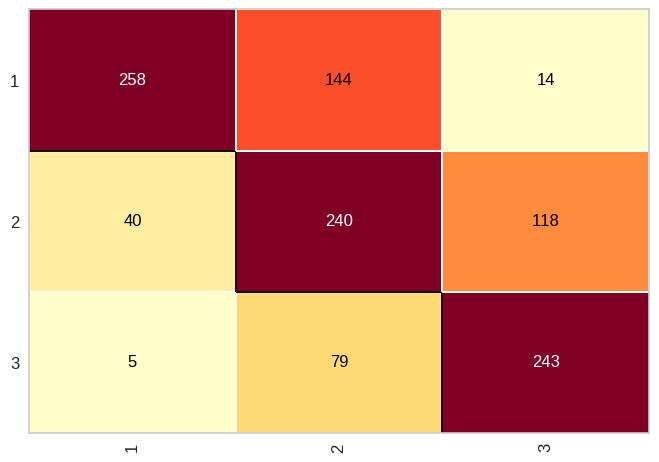

In [51]:
cm = ConfusionMatrix(modelo)
cm.fit(X_treino, y_treino)
cm.score(X_teste, y_teste)

In [52]:
importances = modelo.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_treino.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_importance)

                                  Feature  Importance
4                                   Nível    0.784960
6   Tempo_de_experiencia_na_area_de_dados    0.109110
3                         Nivel_de_Ensino    0.041948
0                                    IDHM    0.025957
5                                  Python    0.022901
10                                  Uf_BA    0.003007
1                             PIB_2021_OR    0.002495
13                                  Uf_ES    0.002462
8                                   Uf_AM    0.002259
16                                  Uf_MG    0.002153
18                                  Uf_MT    0.001398
2                            Faixa_Etaria    0.001350
11                                  Uf_CE    0.000000
12                                  Uf_DF    0.000000
7                                   Uf_AL    0.000000
9                                   Uf_AP    0.000000
15                                  Uf_MA    0.000000
14                          

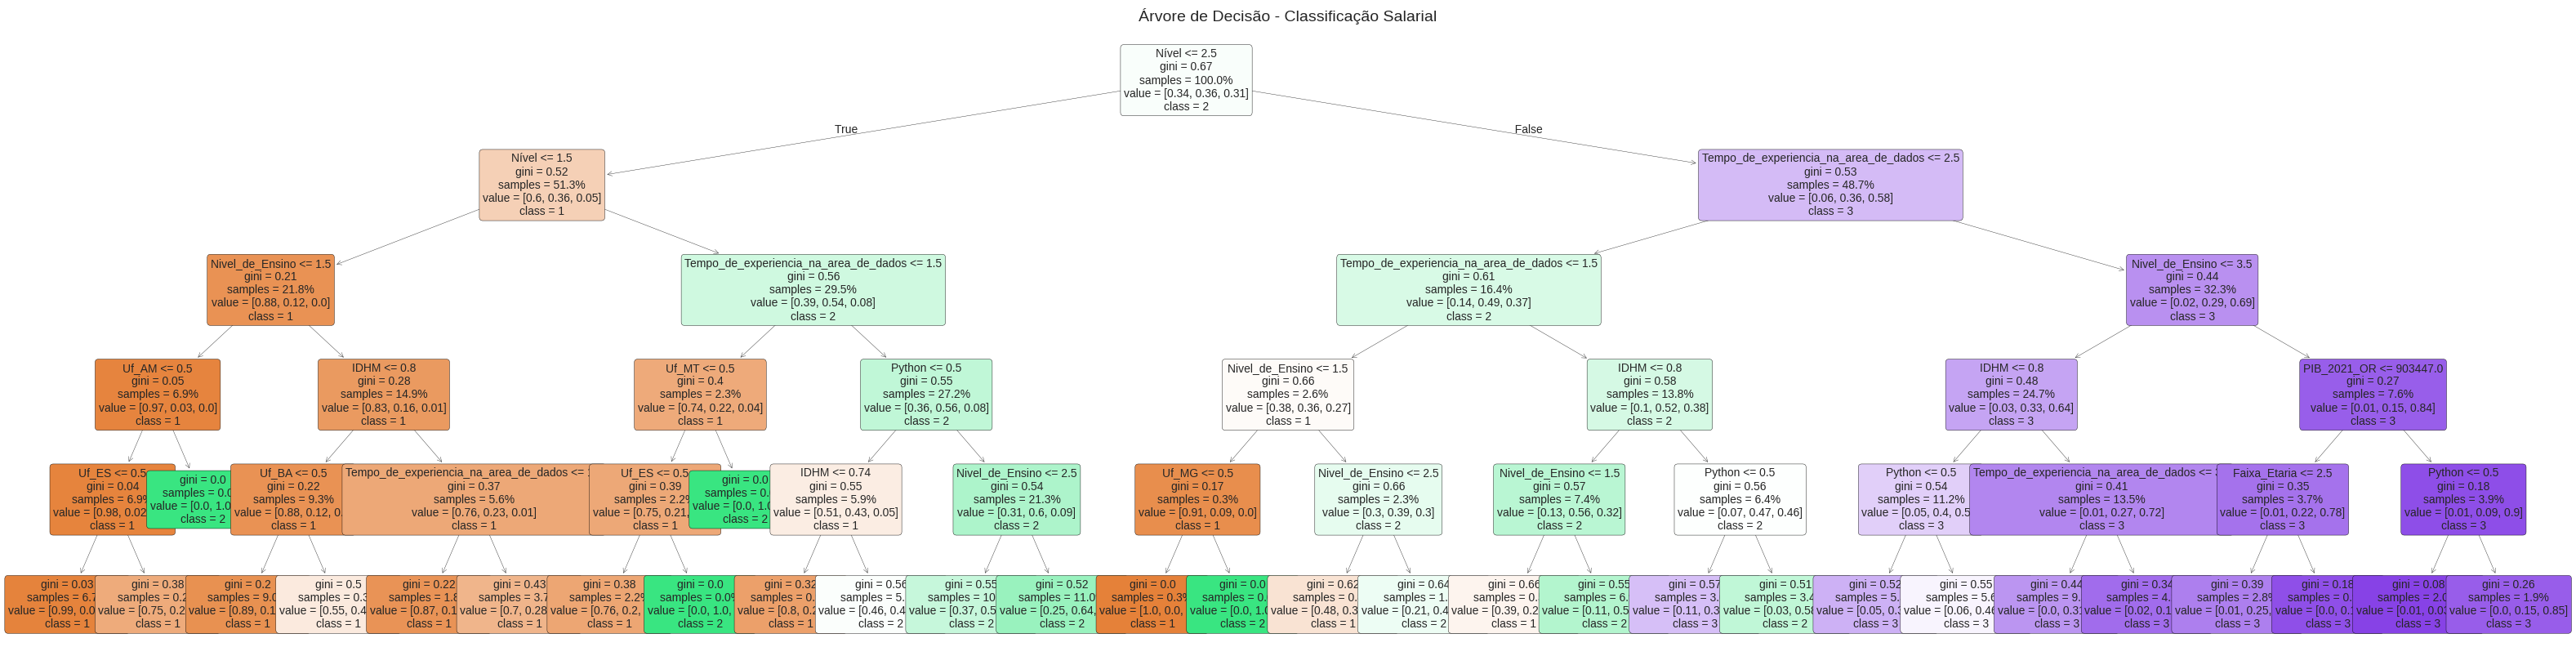

In [53]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Configurações para uma visualização clara
plt.figure(figsize=(40,10))  # Ajuste o tamanho conforme necessário

# Plot da árvore com parâmetros otimizados
plot_tree(modelo,
          feature_names=X_treino.columns.tolist(),  # Nomes das features
          class_names=['1', '2', '3', '4'],         # Nomes das classes
          filled=True,                              # Preenchimento de cores
          rounded=True,                             # Bordas arredondadas
          proportion=True,                          # Mostra proporções
          precision=2,                              # Casas decimais
          fontsize=10)                              # Tamanho da fonte

plt.title("Árvore de Decisão - Classificação Salarial", fontsize=14)
plt.show()

In [54]:
base_treino.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4564 entries, 0 to 5290
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   IDHM                                   4564 non-null   float64
 1   PIB_2021_OR                            4564 non-null   float64
 2   Faixa_Etaria                           4564 non-null   int64  
 3   Nivel_de_Ensino                        4564 non-null   int64  
 4   Nível                                  3711 non-null   float64
 5   Nivel_Salarial                         4564 non-null   int64  
 6   Python                                 4564 non-null   int64  
 7   Tempo_de_experiencia_na_area_de_dados  4564 non-null   int64  
 8   Uf_AL                                  4564 non-null   int64  
 9   Uf_AM                                  4564 non-null   int64  
 10  Uf_AP                                  4564 non-null   int64  
 11  Uf_BA    

In [56]:
from google.colab import files
base_treino.to_csv('base_treino.csv', index=False, encoding='utf-8-sig')
files.download('base_treino.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Acurácia de treino: 0.6801
Acurácia de teste: 0.6145


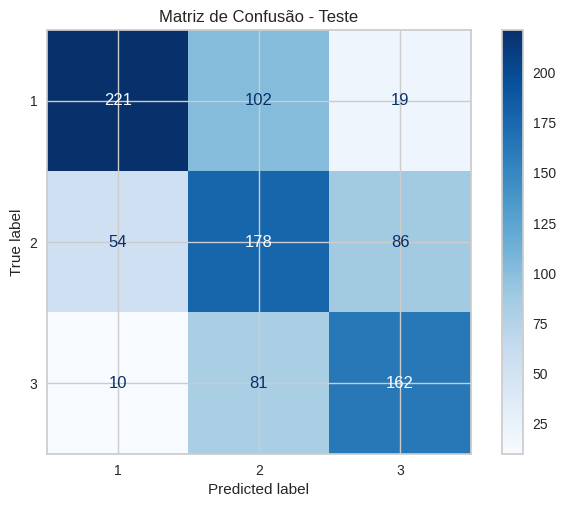


--- Resultados Detalhados do Modelo KNN no Conjunto de Teste ---

Acurácia no conjunto de teste: 0.61

Matriz de Confusão (Texto):
[[221 102  19]
 [ 54 178  86]
 [ 10  81 162]]

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.78      0.65      0.70       342
           2       0.49      0.56      0.52       318
           3       0.61      0.64      0.62       253

    accuracy                           0.61       913
   macro avg       0.63      0.62      0.62       913
weighted avg       0.63      0.61      0.62       913


Calculando a importância das características (usando o conjunto de teste)...

Importância das Características (Permutation Importance - Teste):
                                  Feature  Importance
4                                   Nível    0.128697
6   Tempo_de_experiencia_na_area_de_dados    0.048083
5                                  Python    0.036254
23                                  Uf_PR    0.0086

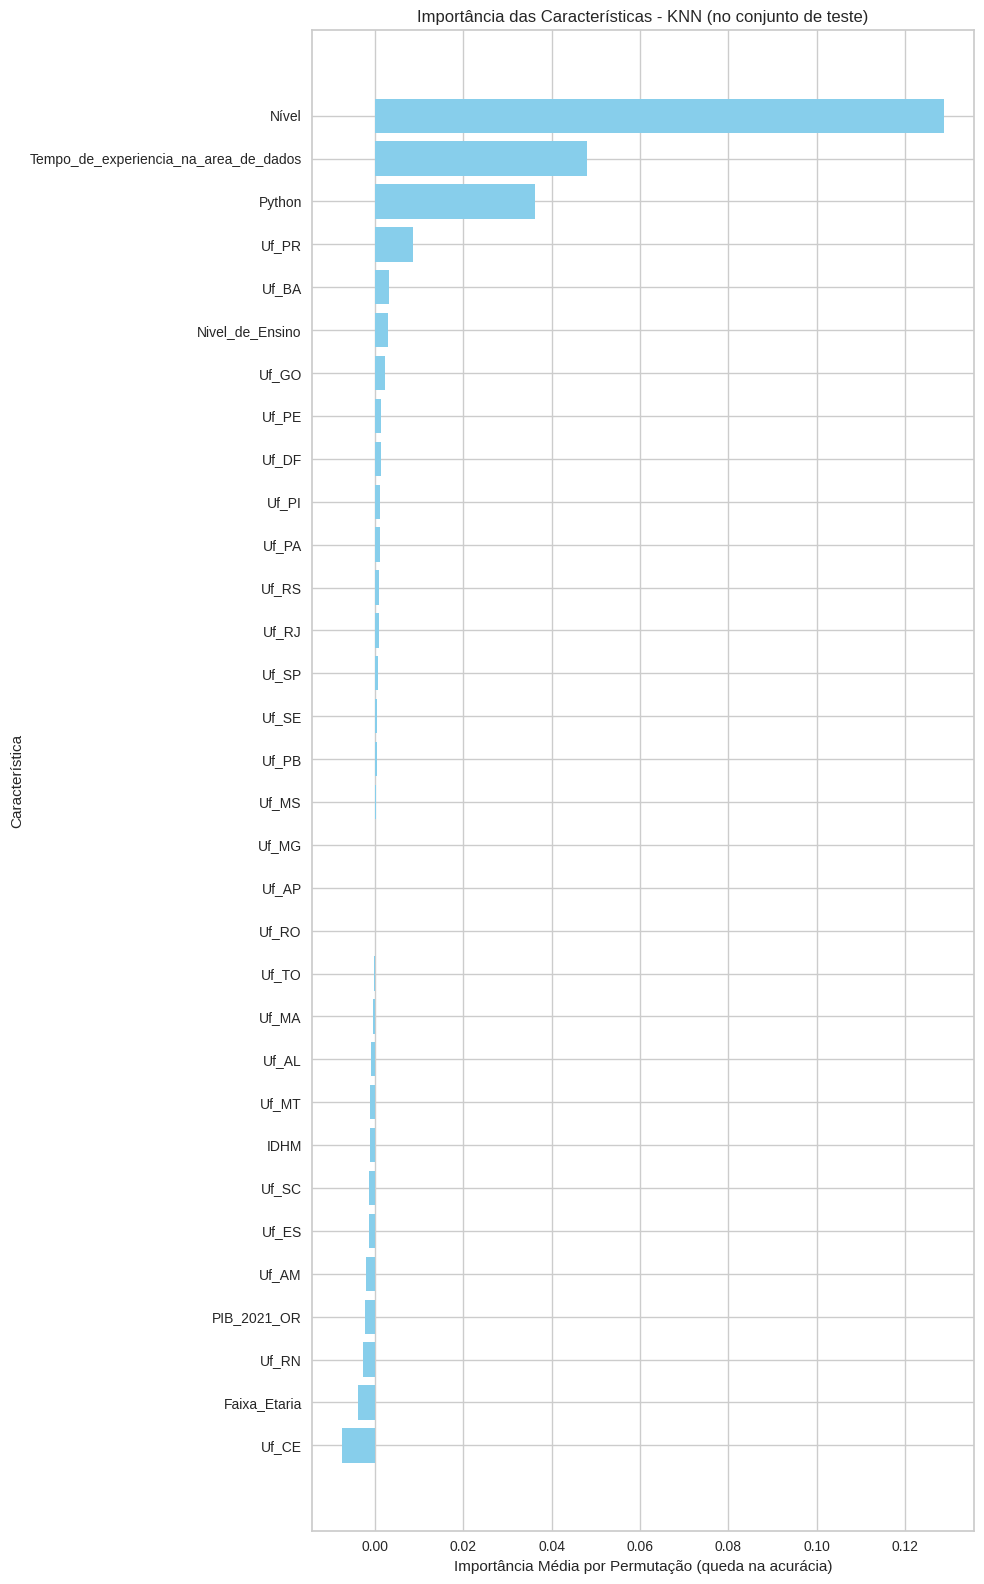

In [60]:
#Segundo modelo Induzido
#KNN ou K-Vizinhos Mais Próximos
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance # <--- IMPORTANTE

# Imputação dos valores ausentes na coluna "Nível"
imputer = SimpleImputer(strategy='mean')
# Certifique-se de que a coluna 'Nível' existe em base_treino
if 'Nível' in base_treino.columns:
    base_treino['Nível'] = imputer.fit_transform(base_treino[['Nível']])
else:
    print("Aviso: Coluna 'Nível' não encontrada para imputação.")


# Separando features (X) e target (y)
X = base_treino.drop('Nivel_Salarial', axis=1)
y = base_treino['Nivel_Salarial']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalonamento dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinamento do modelo KNN
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)

# Previsões
y_pred_train = knn.predict(X_train_scaled)
y_pred_test = knn.predict(X_test_scaled)

# Acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia de treino: {acc_train:.4f}")
print(f"Acurácia de teste: {acc_test:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_) # Adicionado display_labels
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Teste")
plt.show()

print("\n--- Resultados Detalhados do Modelo KNN no Conjunto de Teste ---")


print(f"\nAcurácia no conjunto de teste: {acc_test:.2f}")

# 2. Matriz de Confusão (texto)
print("\nMatriz de Confusão (Texto):")
cm_text = confusion_matrix(y_test, y_pred_test)
print(cm_text)

# 3. Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_test, zero_division=0)) # Adicionado zero_division=0

# ---------------------------------------------------------------------------
# CÁLCULO DA IMPORTÂNCIA DAS CARACTERÍSTICAS USANDO PERMUTATION IMPORTANCE
# ---------------------------------------------------------------------------
print("\nCalculando a importância das características (usando o conjunto de teste)...")

result = permutation_importance(
    estimator=knn,
    X=X_test_scaled,  # Usando dados de teste para avaliação da importância
    y=y_test,
    scoring='accuracy', # Mesma métrica usada para avaliação do modelo, ou outra de interesse
    n_repeats=10,       # Número de repetições para maior robustez
    random_state=42,
    n_jobs=-1
)

# Extrair as importâncias médias
importances = result.importances_mean

# Obter os nomes das características
# X_train é o DataFrame ANTES do escalonamento e contém os nomes das colunas
feature_names = X_train.columns

# Criar o DataFrame de importância das características
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nImportância das Características (Permutation Importance - Teste):")
print(feature_importance_df)

# Opcional: Plotar a importância das características
if not feature_importance_df.empty:
    plt.figure(figsize=(10, max(6, len(feature_names) * 0.5))) # Ajusta altura do gráfico
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.xlabel("Importância Média por Permutação (queda na acurácia)")
    plt.ylabel("Característica")
    plt.title("Importância das Características - KNN (no conjunto de teste)")
    plt.gca().invert_yaxis()  # Característica mais importante no topo
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame de importância das características está vazio, não é possível plotar.")



Gerando a Curva de Aprendizado...


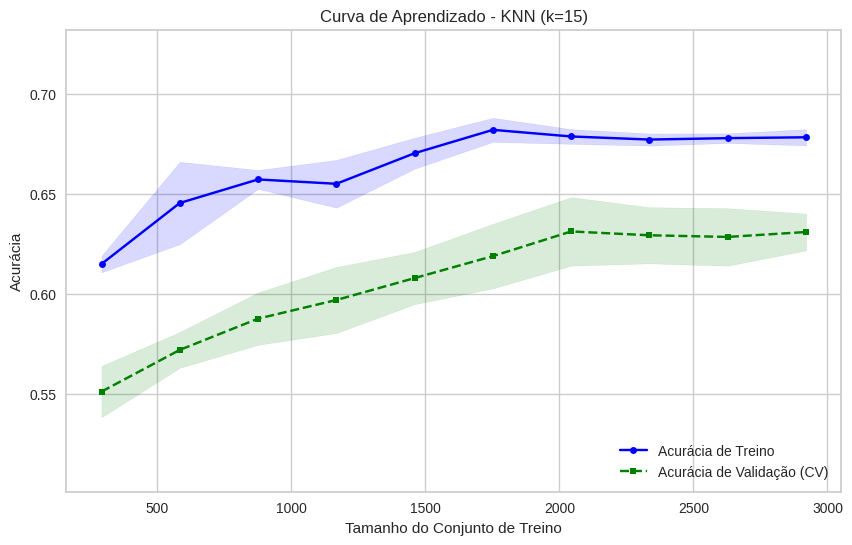

In [58]:
# CURVA DE APRENDIZADO

from sklearn.model_selection import learning_curve

print("\nGerando a Curva de Aprendizado...")

estimator_for_lc = KNeighborsClassifier(n_neighbors=15)

# Gerando os dados para a Curva de Aprendizado
# Usamos X_train_scaled e y_train, pois o modelo é treinado com dados escalonados.
train_sizes, train_scores, test_scores = learning_curve(
    estimator=estimator_for_lc,
    X=X_train_scaled,
    y=y_train,
    cv=5,  # Número de folds para validação cruzada (pode ajustar)
    n_jobs=-1, # Usar todos os processadores
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 tamanhos de treino, de 10% a 100%
    scoring='accuracy' # Métrica de avaliação
)

# Calculando médias e desvios padrão das pontuações
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotando a Curva de Aprendizado
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Acurácia de Treino')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Acurácia de Validação (CV)')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.title(f'Curva de Aprendizado - KNN (k={knn.n_neighbors})') # Usa o k do seu modelo principal
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True)
plt.ylim([min(test_mean.min(), train_mean.min()) - 0.05, max(test_mean.max(), train_mean.max()) + 0.05]) # Ajusta limites do eixo Y
plt.show()
